# 模块 8：状态机（`/state_machine`）调用示例

对应 `design/函数接口.md` 模块 8，演示三个部分：

1. `evaluate_visual_lock(detections, visual_tracks, conf_thresh, area_thresh)` —— 视觉锁定进入条件判定（单帧）；
2. `evaluate_radar_lost(radar_tracks)` —— 雷达丢失判定（单帧）；
3. `transition(state, visual_lock, radar_lost, counters)` —— 状态转移（含 N/M/K 计数）。

三态闭环：`RADAR_GUIDE` —(视觉锁定连续 N 帧)→ `VISUAL_LOCK` —(连续 M 帧丢失)→ `RADAR_GUIDE`；
`RADAR_GUIDE` —(雷达丢失连续 K 帧)→ `SEARCH/RTH` —(雷达恢复)→ `RADAR_GUIDE`。

本 notebook 包含 **4 个场景**：

| 场景 | 内容 |
|---|---|
| 1 | 单帧判定：置信度 / 面积比 / 严格大于边界 |
| 2 | 帧驱动状态机：N/M/K 触发与状态轨迹 |
| 3 | 优先级：视觉锁定 > 雷达丢失 |
| 4 | 开发 / 上机阶段开关 |

> 范围说明：状态机**无发布时钟**，`/state` 按变化发布，帧计数以数据消息到达为节拍（设计原则第 4 条）。
> 本模块只做**纯逻辑**（无 ROS 依赖），节点壳（订阅 / 发布 / 切换日志）在集成阶段封装。

In [1]:
import os
import sys
import importlib
import warnings

# 确保可 import 同目录下的 state_machine / datatypes / config
sys.path.insert(0, os.path.abspath('.'))

%matplotlib inline
import matplotlib.pyplot as plt

import state_machine as sm
from datatypes import DetectedTarget, VisualTrack, Track

print('state_machine.STAGE =', sm.STAGE, '| ONBOARD =', sm.ONBOARD,
      '| N/M/K =', sm.N_VISUAL_LOCK, '/', sm.M_VISUAL_LOST, '/', sm.K_RADAR_LOST)

state_machine.STAGE = dev | ONBOARD = False | N/M/K = 3 / 3 / 5


## 0. 辅助

- `det(conf)` / `vtrack(area)` / `rtrack(id)`：构造消息级输入（仅取判定所需字段）；
- 配色沿用 `design` 模块着色：**雷达蓝** `RADAR_GUIDE`、**视觉紫** `VISUAL_LOCK`、**兜底红** `SEARCH/RTH`。

In [2]:
C_RADAR = '#1565c0'   # 雷达引导蓝（与 design 模块配色一致）
C_VISUAL = '#7b1fa2'  # 视觉锁定紫
C_SEARCH = '#c62828'  # SEARCH/RTH 兜底红
STATE_COLOR = {
    sm.STATE_RADAR_GUIDE: C_RADAR,
    sm.STATE_VISUAL_LOCK: C_VISUAL,
    sm.STATE_SEARCH_RTH: C_SEARCH,
}

# 中文字体（环境自带 Noto Sans CJK），保证标题 / 图例正常显示
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def det(conf):
    """构造一条检测结果（仅取置信度）。"""
    return DetectedTarget(class_id=0, confidence=conf, bbox=(10.0, 10.0, 20.0, 20.0))


def vtrack(area):
    """构造一条视觉航迹（仅取面积比）。"""
    return VisualTrack(id=1, bbox=(10.0, 10.0, 20.0, 20.0), area_ratio=area)


def rtrack(tid=1):
    """构造一条雷达航迹。"""
    return Track(id=tid, position=(1.0, 2.0, 3.0), velocity=(0.0, 0.0, 0.0),
                 covariance=tuple([0.0] * 36), age=1)


def new_counters():
    """新建一份 N/M/K 计数器。"""
    return {'visual_lock': 0, 'visual_lost': 0, 'radar_lost': 0}

## 1. 单帧判定

`evaluate_visual_lock` 采用**存在性判定**：存在任一 `confidence > 0.8` 的检测 **且**
任一 `area_ratio > 0.02` 的视觉航迹才返回 `True`；比较为**严格大于**（等于阈值不满足）。
`evaluate_radar_lost` 仅看雷达航迹是否为空。

In [3]:
cases = [
    ('双条件满足',      [det(0.90)], [vtrack(0.05)]),
    ('置信度不足',      [det(0.50)], [vtrack(0.05)]),
    ('面积比不足',      [det(0.90)], [vtrack(0.01)]),
    ('等于阈值(严格>)', [det(0.80)], [vtrack(0.02)]),
    ('无目标(空)',      [],          []),
]

print('【evaluate_visual_lock】默认阈值 conf>0.8, area>0.02')
print('%-18s %-10s %-10s %s' % ('场景', '最大置信度', '最大面积比', '结果'))
print('-' * 56)
for name, dets, tracks in cases:
    c = max([d.confidence for d in dets], default=0.0)
    a = max([t.area_ratio for t in tracks], default=0.0)
    print('%-18s %-10.2f %-10.3f %s'
          % (name, c, a, sm.evaluate_visual_lock(dets, tracks)))

print()
print('【evaluate_radar_lost】')
print('  无雷达航迹 ->', sm.evaluate_radar_lost([]))
print('  有雷达航迹 ->', sm.evaluate_radar_lost([rtrack()]))

【evaluate_visual_lock】默认阈值 conf>0.8, area>0.02
场景                 最大置信度      最大面积比      结果
--------------------------------------------------------
双条件满足              0.90       0.050      True
置信度不足              0.50       0.050      False
面积比不足              0.90       0.010      False
等于阈值(严格>)          0.80       0.020      False
无目标(空)             0.00       0.000      False

【evaluate_radar_lost】
  无雷达航迹 -> True
  有雷达航迹 -> False


## 2. 帧驱动状态机

以一连串「帧」驱动状态机：每帧给出雷达航迹、检测、视觉航迹，先各自判定，
再调 `transition` 推进状态（`counters` 原地更新）。

In [4]:
# 每帧传感器输入：(雷达航迹条数, 检测置信度列表, 视觉航迹面积比列表)
frames = [
    (1, [],           []),        # 仅雷达
    (1, [],           []),
    (1, [0.90, 0.40], [0.05]),    # 视觉条件满足，开始连续计数
    (1, [0.92],       [0.06]),
    (1, [0.95],       [0.07]),    # 连续第 3 帧 → 进入 VISUAL_LOCK
    (1, [0.91],       [0.08]),    # 视觉保持
    (1, [],           []),        # 视觉丢失 1
    (1, [],           []),        # 视觉丢失 2
    (1, [],           []),        # 视觉丢失 3 → 回 RADAR_GUIDE
    (0, [],           []),        # 雷达丢失 1
    (0, [],           []),
    (0, [],           []),
    (0, [],           []),
    (0, [],           []),        # 雷达丢失 5 → 进入 SEARCH/RTH
    (1, [],           []),        # 雷达恢复 → 回 RADAR_GUIDE
    (1, [0.93],       [0.09]),
    (1, [0.94],       [0.10]),
    (1, [0.95],       [0.11]),    # 再次进入 VISUAL_LOCK
]

counters = new_counters()
state = sm.STATE_RADAR_GUIDE
rows = []
for i, (n_radar, confs, areas) in enumerate(frames):
    radar_tracks = [rtrack(j) for j in range(n_radar)]
    dets = [det(c) for c in confs]
    tracks = [vtrack(a) for a in areas]

    visual_lock = sm.evaluate_visual_lock(dets, tracks)
    radar_lost = sm.evaluate_radar_lost(radar_tracks)
    new_state = sm.transition(state, visual_lock, radar_lost, counters)
    rows.append((i, state, new_state, visual_lock, radar_lost, dict(counters)))
    state = new_state

print('%3s  %-12s  %-12s  %-6s  %-6s  %s'
      % ('帧', '原状态', '新状态', '视觉锁', '雷达丢', '计数(锁/失/丢)'))
print('-' * 78)
for i, old, new, vl, rl, cnt in rows:
    mark = '  <== 切换' if new != old else ''
    print('%3d  %-12s  %-12s  %-6s  %-6s  %d/%d/%d%s'
          % (i, old, new, vl, rl,
             cnt['visual_lock'], cnt['visual_lost'], cnt['radar_lost'], mark))

  帧  原状态           新状态           视觉锁     雷达丢     计数(锁/失/丢)
------------------------------------------------------------------------------
  0  RADAR_GUIDE   RADAR_GUIDE   False   False   0/0/0
  1  RADAR_GUIDE   RADAR_GUIDE   False   False   0/0/0
  2  RADAR_GUIDE   RADAR_GUIDE   True    False   1/0/0
  3  RADAR_GUIDE   RADAR_GUIDE   True    False   2/0/0
  4  RADAR_GUIDE   VISUAL_LOCK   True    False   0/0/0  <== 切换
  5  VISUAL_LOCK   VISUAL_LOCK   True    False   0/0/0
  6  VISUAL_LOCK   VISUAL_LOCK   False   False   0/1/0
  7  VISUAL_LOCK   VISUAL_LOCK   False   False   0/2/0
  8  VISUAL_LOCK   RADAR_GUIDE   False   False   0/0/0  <== 切换
  9  RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/1
 10  RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/2
 11  RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/3
 12  RADAR_GUIDE   RADAR_GUIDE   False   True    0/0/4
 13  RADAR_GUIDE   SEARCH/RTH    False   True    0/0/0  <== 切换
 14  SEARCH/RTH    RADAR_GUIDE   False   False   0/0/0  <== 切换
 15  

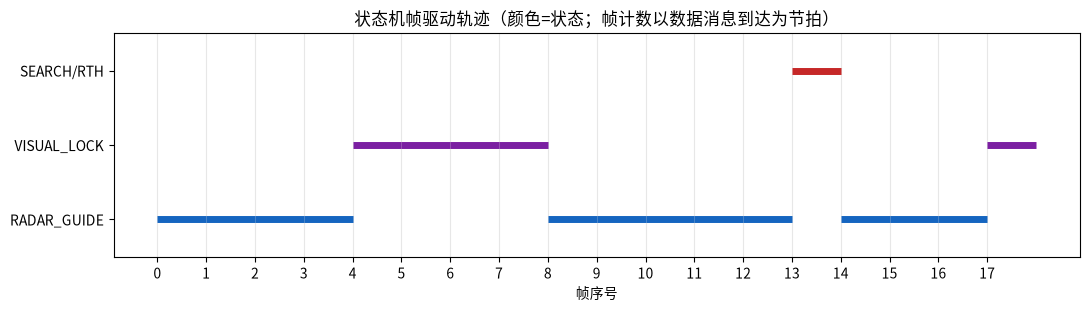

In [5]:
# 状态轨迹图：颜色 = 状态
order = {sm.STATE_RADAR_GUIDE: 0, sm.STATE_VISUAL_LOCK: 1, sm.STATE_SEARCH_RTH: 2}

fig, ax = plt.subplots(figsize=(11, 3.2))
for i, (_, _old, new, _vl, _rl, _cnt) in enumerate(rows):
    ax.plot([i, i + 1], [order[new], order[new]],
            color=STATE_COLOR[new], lw=5, solid_capstyle='butt')

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['RADAR_GUIDE', 'VISUAL_LOCK', 'SEARCH/RTH'])
ax.set_xticks([i for i, *_ in rows])
ax.set_xlabel('帧序号')
ax.set_ylim(-0.5, 2.5)
ax.set_title('状态机帧驱动轨迹（颜色=状态；帧计数以数据消息到达为节拍）')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 优先级：视觉锁定 > 雷达丢失

`RADAR_GUIDE` 下若视觉锁定与雷达丢失**同时**成立，`visual_lock` 与 `radar_lost`
各自独立计数，但 **视觉锁定优先**：达 `N` 帧即进 `VISUAL_LOCK`。

In [6]:
counters = new_counters()
state = sm.STATE_RADAR_GUIDE
print('%3s  %-14s  %s' % ('帧', '状态', '计数(锁/丢)'))
print('-' * 40)
for i in range(sm.N_VISUAL_LOCK + 1):
    state = sm.transition(state, True, True, counters)  # 视觉与雷达丢失同时成立
    print('%3d  %-14s  %d/%d' % (i, state, counters['visual_lock'], counters['radar_lost']))

print('\n→ 二者同时成立时视觉优先：第 %d 帧进入 VISUAL_LOCK（未滑向 SEARCH/RTH）'
      % sm.N_VISUAL_LOCK)

  帧  状态              计数(锁/丢)
----------------------------------------
  0  RADAR_GUIDE     1/1
  1  RADAR_GUIDE     2/2
  2  VISUAL_LOCK     0/0
  3  VISUAL_LOCK     0/0

→ 二者同时成立时视觉优先：第 3 帧进入 VISUAL_LOCK（未滑向 SEARCH/RTH）


## 4. 开发 / 上机阶段开关

由环境变量 `UAV_STAGE` 控制（见 `code/config.py`）：

- `dev`（默认）：非法输入直接抛 `ValueError`，问题尽早暴露；
- `onboard`：非法输入发 `RuntimeWarning` 并走安全默认分支（不崩溃）。

In [7]:
import config

# --- dev（默认）：非法输入直接抛错 ---
os.environ.pop('UAV_STAGE', None)
importlib.reload(config)
importlib.reload(sm)
print('当前 STAGE =', sm.STAGE, '| ONBOARD =', sm.ONBOARD)
try:
    sm.evaluate_radar_lost(None)
except ValueError as e:
    print('[dev] 抛错:', e)

# --- onboard：告警 + 安全默认（无法判断按丢失）---
os.environ['UAV_STAGE'] = 'onboard'
importlib.reload(config)
importlib.reload(sm)
print('\n重载后 STAGE =', sm.STAGE, '| ONBOARD =', sm.ONBOARD)
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    out = sm.evaluate_radar_lost(None)
print('onboard 下 evaluate_radar_lost(None) 返回:', out, '| 告警数:', len(w))
print('告警内容:', str(w[0].message) if w else None)

# 还原环境，避免影响后续运行
os.environ.pop('UAV_STAGE', None)
importlib.reload(config)
importlib.reload(sm)
print('\n已还原 STAGE =', sm.STAGE)

当前 STAGE = dev | ONBOARD = False
[dev] 抛错: [state_machine] evaluate_radar_lost: radar_tracks 必须为 list，实际为 None

重载后 STAGE = onboard | ONBOARD = True
onboard 下 evaluate_radar_lost(None) 返回: True | 告警数: 1
告警内容: [state_machine] evaluate_radar_lost: radar_tracks 必须为 list，实际为 None；上机阶段按默认值处理

已还原 STAGE = dev
